# Aufgabe 1b: CNN von Grund auf (ohne keras.models / keras.layers)

## Beschreibung

In dieser Aufgabe wird ein CNN **vollständig in Python/NumPy** implementiert – ohne `keras.models` oder `keras.layers`. Ziel ist es, die mathematischen Grundlagen der Vorwärts- und Rückwärtspropagation durch eigenen Code zu verstehen und nachzuvollziehen.

### Lösungsansatz

Der Lösungsweg gliedert sich in folgende Schritte:

1. **Schicht-Implementierungen (Forward + Backward)** – Jede Schicht wird als Paar aus Forward- und Backward-Funktion implementiert. Der Forward-Pass berechnet die Ausgabe und speichert alle für den Rückwärtspass nötigen Zwischenwerte im *Cache*. Der Backward-Pass berechnet Gradienten mithilfe der Kettenregel.

2. **Numerischer Gradientencheck** – Vor dem Training wird die Korrektheit der Backpropagation durch numerische Differentiation verifiziert: `(f(x+ε) - f(x-ε)) / (2ε)`. Der relative Fehler zwischen analytischem und numerischem Gradient muss < 1e-4 sein. Dieser Schritt ist essenziell – fehlerhafte Gradienten führen zu falschem Training, das erst spät auffällt.

3. **Modell und Training** – Das vollständige CNN wird durch sequenzielles Aufrufen der Schichtfunktionen aufgebaut. SGD mit Momentum wird als Optimizer verwendet. Das Training läuft auf einem Subset des CIFAR-10-Datensatzes.

4. **Evaluation** – Das beste Modell (höchste Validation Accuracy) wird gespeichert und abschließend auf den Testdaten ausgewertet.

### Architektur
```
Input (N, 3, 32, 32) [Channels-First]
  → Conv2D: 8 Filter, 3×3, valid → (N, 8, 30, 30)
  → ReLU
  → MaxPool 2×2, Stride 2 → (N, 8, 15, 15)
  → Flatten → (N, 1800)
  → Dense 1800 → 256, ReLU
  → Dense 256 → 10, Softmax
```

**Wichtig:** `keras.datasets` zum Laden der Daten ist ausdrücklich erlaubt. Nur `keras.models` und `keras.layers` sind verboten.

## 1. Imports

In [24]:
import numpy as np
from tensorflow import keras  # NUR für Datenladen erlaubt
import matplotlib.pyplot as plt
import time

# Reproduzierbarkeit
np.random.seed(42)

CIFAR10_CLASSES = ['Flugzeug', 'Automobil', 'Vogel', 'Katze', 'Hirsch',
                   'Hund', 'Frosch', 'Pferd', 'Schiff', 'LKW']

print("NumPy Version:", np.__version__)
print("Hinweis: Kein keras.models, kein keras.layers - nur NumPy!")

NumPy Version: 2.4.4
Hinweis: Kein keras.models, kein keras.layers - nur NumPy!


## 2. Daten laden

In [25]:
# Daten laden (keras.datasets ist erlaubt)
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

y_train = y_train.ravel()
y_test  = y_test.ravel()

# Normalisierung auf [0, 1]
x_train = x_train.astype(np.float64) / 255.0
x_test  = x_test.astype(np.float64) / 255.0

# Channels-First: (N, H, W, C) → (N, C, H, W)
x_train = x_train.transpose(0, 3, 1, 2)
x_test  = x_test.transpose(0, 3, 1, 2)

print(f"Training: {x_train.shape}, Labels: {y_train.shape}")
print(f"Test:     {x_test.shape}, Labels: {y_test.shape}")
print(f"Format: Channels-First (N, C, H, W)")

N_TRAIN = 5000
idx_train = np.random.choice(len(x_train), N_TRAIN, replace=False)
x_train_sub = x_train[idx_train]
y_train_sub = y_train[idx_train]
print(f"\nVerwendete Trainingsdaten: {N_TRAIN}")

Training: (50000, 3, 32, 32), Labels: (50000,)
Test:     (10000, 3, 32, 32), Labels: (10000,)
Format: Channels-First (N, C, H, W)

Verwendete Trainingsdaten: 5000


## 3. Schicht-Implementierungen

Jede Schicht wird als **Forward- und Backward-Funktion** implementiert. Der Forward-Pass speichert alle für den Backward-Pass nötigen Zwischenwerte im **Cache**.

In [26]:
# ==========================================
# Konvolutions-Schicht
# ==========================================

def conv2d_forward(X, W, b):
    """
    Vorwärtspass der 2D-Faltung (Kreuzkorrelation).
    
    Args:
        X: Eingabe (N, C_in, H, W)
        W: Filtergewichte (C_out, C_in, kH, kW)
        b: Bias (C_out,)
    
    Returns:
        out: Ausgabe (N, C_out, H_out, W_out) mit H_out = H - kH + 1
        cache: (X, W, b) für Backward-Pass
    """
    N, C_in, H, W_in = X.shape
    C_out, _, kH, kW = W.shape
    H_out = H - kH + 1
    W_out = W_in - kW + 1
    
    out = np.zeros((N, C_out, H_out, W_out), dtype=X.dtype)
    
    for n in range(N):
        for f in range(C_out):
            for i in range(H_out):
                for j in range(W_out):
                    # Elementweises Produkt: Fenster * Filter, dann summieren
                    out[n, f, i, j] = np.sum(
                        X[n, :, i:i+kH, j:j+kW] * W[f]
                    ) + b[f]
    
    cache = (X, W, b)
    return out, cache


def conv2d_backward(dout, cache):
    """
    Rückwärtspass der 2D-Faltung.
    
    dX verwendet gedrehten Kernel (Faltung, nicht Kreuzkorrelation).
    
    Args:
        dout: Gradient (N, C_out, H_out, W_out)
        cache: (X, W, b) aus Forward-Pass
    
    Returns:
        dX: Gradient bzgl. Eingabe (N, C_in, H, W)
        dW: Gradient bzgl. Gewichten (C_out, C_in, kH, kW)
        db: Gradient bzgl. Bias (C_out,)
    """
    X, W, b = cache
    N, C_in, H, W_in = X.shape
    C_out, _, kH, kW = W.shape
    _, _, H_out, W_out = dout.shape
    
    dX = np.zeros_like(X)
    dW = np.zeros_like(W)
    db = np.zeros_like(b)
    
    # db[f] = Summe aller Gradienten für Filter f
    db = dout.sum(axis=(0, 2, 3))  # (C_out,)
    
    # dW[f,c,i,j] = sum_{n,h,w} dout[n,f,h,w] * X[n,c,h+i,w+j]
    for n in range(N):
        for f in range(C_out):
            for i in range(kH):
                for j in range(kW):
                    dW[f, :, i, j] += np.sum(
                        dout[n, f, :, :, np.newaxis] *
                        X[n, :, i:i+H_out, j:j+W_out].transpose(1, 0, 2).reshape(1, C_in, H_out, W_out).transpose(0, 2, 3, 1),
                        axis=(0, 1, 2)
                    ) if False else 0
    
    # Effizientere Berechnung von dW
    dW = np.zeros_like(W)
    for n in range(N):
        for f in range(C_out):
            for h in range(H_out):
                for w in range(W_out):
                    dW[f] += dout[n, f, h, w] * X[n, :, h:h+kH, w:w+kW]
    
    # dX: Volle Faltung mit gedrehtem Kernel
    # W_flip[f,c,i,j] = W[f,c,kH-1-i,kW-1-j]
    W_flip = np.flip(W, axis=(2, 3))  # (C_out, C_in, kH, kW)
    
    # Padding für dout: pad um (kH-1, kW-1)
    dout_padded = np.pad(dout, ((0,0),(0,0),(kH-1,kH-1),(kW-1,kW-1)))
    
    for n in range(N):
        for c in range(C_in):
            for i in range(H):
                for j in range(W_in):
                    dX[n, c, i, j] = np.sum(
                        dout_padded[n, :, i:i+kH, j:j+kW] * W_flip[:, c, :, :]
                    )
    
    return dX, dW, db


print("Konvolutions-Schicht definiert.")

Konvolutions-Schicht definiert.


In [27]:
# ==========================================
# ReLU-Aktivierung
# ==========================================

def relu_forward(X):
    """ReLU: max(0, X). Cache speichert X für Backward-Pass."""
    out   = np.maximum(0, X)
    cache = X
    return out, cache


def relu_backward(dout, cache):
    """Gradient durch ReLU: dout, wenn X > 0, sonst 0."""
    X  = cache
    dX = dout * (X > 0)
    return dX


print("ReLU-Aktivierung definiert.")

ReLU-Aktivierung definiert.


In [28]:
# ==========================================
# MaxPooling-Schicht
# ==========================================

def maxpool_forward(X, pool_size=2, stride=2):
    """
    Max-Pooling Vorwärtspass.
    
    Args:
        X: (N, C, H, W)
        pool_size: Fenstergröße
        stride: Schrittgröße
    
    Returns:
        out: (N, C, H//stride, W//stride)
        cache: (X, pool_size, stride, argmax_mask)
    """
    N, C, H, W = X.shape
    H_out = (H - pool_size) // stride + 1
    W_out = (W - pool_size) // stride + 1
    
    out  = np.zeros((N, C, H_out, W_out), dtype=X.dtype)
    mask = np.zeros_like(X)  # 1 wo der Maximalwert war
    
    for n in range(N):
        for c in range(C):
            for i in range(H_out):
                for j in range(W_out):
                    h_start = i * stride
                    w_start = j * stride
                    window  = X[n, c, h_start:h_start+pool_size, w_start:w_start+pool_size]
                    max_val = window.max()
                    out[n, c, i, j] = max_val
                    
                    # Maske: 1 an der Position des Maximalwerts
                    max_pos = np.unravel_index(window.argmax(), window.shape)
                    mask[n, c, h_start + max_pos[0], w_start + max_pos[1]] = 1
    
    cache = (X, pool_size, stride, mask)
    return out, cache


def maxpool_backward(dout, cache):
    """
    Max-Pooling Rückwärtspass.
    Gradient wird nur zur Max-Position weitergeleitet.
    """
    X, pool_size, stride, mask = cache
    N, C, H, W = X.shape
    H_out, W_out = dout.shape[2], dout.shape[3]
    
    dX = np.zeros_like(X)
    
    for n in range(N):
        for c in range(C):
            for i in range(H_out):
                for j in range(W_out):
                    h_start = i * stride
                    w_start = j * stride
                    # Gradient nur an Max-Position
                    dX[n, c, h_start:h_start+pool_size, w_start:w_start+pool_size] += (
                        mask[n, c, h_start:h_start+pool_size, w_start:w_start+pool_size] *
                        dout[n, c, i, j]
                    )
    
    return dX


print("MaxPooling-Schicht definiert.")

MaxPooling-Schicht definiert.


In [29]:
# ==========================================
# Flatten-Schicht
# ==========================================

def flatten_forward(X):
    """Flatten: (N, C, H, W) → (N, C*H*W)"""
    cache = X.shape
    out   = X.reshape(X.shape[0], -1)
    return out, cache


def flatten_backward(dout, cache):
    """Reshape zurück zur ursprünglichen Form."""
    return dout.reshape(cache)


# ==========================================
# Vollständig verbundene Schicht (Dense)
# ==========================================

def dense_forward(X, W, b):
    """
    Dense-Schicht Vorwärtspass.
    
    Args:
        X: (N, D_in)
        W: (D_in, D_out)
        b: (D_out,)
    
    Returns:
        out: (N, D_out)
        cache: (X, W, b)
    """
    out   = X @ W + b
    cache = (X, W, b)
    return out, cache


def dense_backward(dout, cache):
    """
    Dense-Schicht Rückwärtspass.
    
    dX = dout @ W.T
    dW = X.T @ dout
    db = sum(dout, axis=0)
    """
    X, W, b = cache
    dX = dout @ W.T
    dW = X.T @ dout
    db = dout.sum(axis=0)
    return dX, dW, db


print("Flatten und Dense-Schichten definiert.")

Flatten und Dense-Schichten definiert.


In [30]:
# ==========================================
# Softmax + Cross-Entropy Verlust (kombiniert)
# ==========================================

def softmax_crossentropy_forward(logits, y_true):
    """
    Kombinierter Softmax + Cross-Entropy für numerische Stabilität.
    
    Die Kombination vermeidet log(0)-Fehler, die bei separater Berechnung auftreten.
    
    Args:
        logits: (N, C) Rohscores
        y_true: (N,) Integer-Klassenindizes
    
    Returns:
        loss: Skalar (mittlerer Cross-Entropy-Verlust)
        cache: (probs, y_true) für Backward-Pass
    """
    # Numerisch stabiles Softmax: Subtrahiere Zeilenmaxima
    shifted = logits - logits.max(axis=1, keepdims=True)
    exp_s   = np.exp(shifted)
    probs   = exp_s / exp_s.sum(axis=1, keepdims=True)  # (N, C)
    
    N    = logits.shape[0]
    # Verlust: -log(p[n, y_true[n]]) gemittelt über alle Beispiele
    loss = -np.log(probs[np.arange(N), y_true] + 1e-12).mean()
    
    cache = (probs, y_true)
    return loss, cache


def softmax_crossentropy_backward(cache):
    """
    Gradient des kombinierten Softmax + Cross-Entropy.
    
    dL/d_logits[n,k] = (probs[n,k] - 1_{k==y_true[n]}) / N
    """
    probs, y_true = cache
    N = probs.shape[0]
    
    dlogits = probs.copy()
    dlogits[np.arange(N), y_true] -= 1
    dlogits /= N
    
    return dlogits


print("Verlustfunktion definiert.")

Verlustfunktion definiert.


## 4. Numerischer Gradientencheck

**Wichtig:** Bevor das Training beginnt, wird die Korrektheit der Backpropagation durch einen numerischen Gradientencheck verifiziert.

Formel: `f(W+ε) - f(W-ε) / (2ε)` für kleine ε = 1e-5

Der relative Fehler zwischen analytischem und numerischem Gradient sollte < 1e-5 sein.

In [31]:
def relative_error(a, b):
    """Relativer Fehler zwischen zwei Arrays."""
    return np.max(np.abs(a - b) / (np.maximum(np.abs(a) + np.abs(b), 1e-8)))


def gradient_check_dense():
    """Numerischer Gradientencheck für Dense-Schicht."""
    np.random.seed(1)
    X = np.random.randn(3, 4).astype(np.float64)
    W = np.random.randn(4, 5).astype(np.float64)
    b = np.random.randn(5).astype(np.float64)
    y = np.array([1, 3, 2])
    
    # Analytischer Gradient
    out, cache = dense_forward(X, W, b)
    loss, loss_cache = softmax_crossentropy_forward(out, y)
    dout = softmax_crossentropy_backward(loss_cache)
    dX, dW, db = dense_backward(dout, cache)
    
    # Numerischer Gradient für W
    eps = 1e-5
    dW_num = np.zeros_like(W)
    for i in range(W.shape[0]):
        for j in range(W.shape[1]):
            W_plus  = W.copy(); W_plus[i, j]  += eps
            W_minus = W.copy(); W_minus[i, j] -= eps
            out_p, _ = dense_forward(X, W_plus,  b)
            out_m, _ = dense_forward(X, W_minus, b)
            loss_p, _ = softmax_crossentropy_forward(out_p, y)
            loss_m, _ = softmax_crossentropy_forward(out_m, y)
            dW_num[i, j] = (loss_p - loss_m) / (2 * eps)
    
    err = relative_error(dW, dW_num)
    print(f"Dense dW relativer Fehler: {err:.2e}  {'✓ OK' if err < 1e-4 else '✗ FEHLER'}")
    return err


def gradient_check_relu():
    """Numerischer Gradientencheck für ReLU."""
    np.random.seed(2)
    X = np.random.randn(4, 5).astype(np.float64)
    
    # Analytischer Gradient (einfaches Durchleiten)
    out, cache = relu_forward(X)
    dout = np.random.randn(*out.shape)
    dX   = relu_backward(dout, cache)
    
    # Numerischer Gradient
    eps = 1e-5
    dX_num = np.zeros_like(X)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            X_p = X.copy(); X_p[i, j] += eps
            X_m = X.copy(); X_m[i, j] -= eps
            out_p, _ = relu_forward(X_p)
            out_m, _ = relu_forward(X_m)
            # Verwende dout als "Verlustgradient"
            dX_num[i, j] = ((out_p * dout) - (out_m * dout)).sum() / (2 * eps)
    
    err = relative_error(dX, dX_num)
    print(f"ReLU dX relativer Fehler:  {err:.2e}  {'✓ OK' if err < 1e-4 else '✗ FEHLER'}")
    return err


print("Gradientencheck-Funktionen definiert. Starte Check...")
print()
err_dense = gradient_check_dense()
err_relu  = gradient_check_relu()

Gradientencheck-Funktionen definiert. Starte Check...

Dense dW relativer Fehler: 7.46e-08  ✓ OK
ReLU dX relativer Fehler:  6.67e-12  ✓ OK


In [32]:
# Gradientencheck für Conv2D (auf kleiner Eingabe wegen Rechenzeit)
def gradient_check_conv():
    """Numerischer Gradientencheck für Conv2D."""
    np.random.seed(3)
    X = np.random.randn(2, 2, 6, 6).astype(np.float64) * 0.1  # (N, C_in, H, W)
    W = np.random.randn(3, 2, 3, 3).astype(np.float64) * 0.1  # (C_out, C_in, kH, kW)
    b = np.random.randn(3).astype(np.float64) * 0.1
    
    # Analytisch
    out, cache = conv2d_forward(X, W, b)
    dout = np.random.randn(*out.shape) * 0.1
    dX, dW, db = conv2d_backward(dout, cache)
    
    # Numerisch für W (einige Elemente)
    eps = 1e-5
    dW_num = np.zeros_like(W)
    for f in range(W.shape[0]):
        for c in range(W.shape[1]):
            for i in range(W.shape[2]):
                for j in range(W.shape[3]):
                    W_p = W.copy(); W_p[f,c,i,j] += eps
                    W_m = W.copy(); W_m[f,c,i,j] -= eps
                    out_p, _ = conv2d_forward(X, W_p, b)
                    out_m, _ = conv2d_forward(X, W_m, b)
                    dW_num[f,c,i,j] = ((out_p - out_m) * dout).sum() / (2 * eps)
    
    err_W = relative_error(dW, dW_num)
    print(f"Conv2D dW relativer Fehler: {err_W:.2e}  {'✓ OK' if err_W < 1e-4 else '✗ FEHLER'}")
    
    # Numerisch für dX (einige Elemente)
    dX_num = np.zeros_like(X)
    for n in range(X.shape[0]):
        for c in range(X.shape[1]):
            for i in range(X.shape[2]):
                for j in range(X.shape[3]):
                    X_p = X.copy(); X_p[n,c,i,j] += eps
                    X_m = X.copy(); X_m[n,c,i,j] -= eps
                    out_p, _ = conv2d_forward(X_p, W, b)
                    out_m, _ = conv2d_forward(X_m, W, b)
                    dX_num[n,c,i,j] = ((out_p - out_m) * dout).sum() / (2 * eps)
    
    err_X = relative_error(dX, dX_num)
    print(f"Conv2D dX relativer Fehler: {err_X:.2e}  {'✓ OK' if err_X < 1e-4 else '✗ FEHLER'}")
    return err_W, err_X

print("Gradientencheck Conv2D (kann etwas dauern)...")
err_W, err_X = gradient_check_conv()

Gradientencheck Conv2D (kann etwas dauern)...
Conv2D dW relativer Fehler: 4.33e-10  ✓ OK
Conv2D dX relativer Fehler: 8.46e-10  ✓ OK


## 5. Modell und Training

In [33]:
# ==========================================
# Gewichtsinitialisierung
# ==========================================

def init_params():
    """
    He-Initialisierung für alle Gewichte.
    He: std = sqrt(2 / fan_in) - gut für ReLU-Netzwerke.
    """
    params = {}
    
    # Conv-Schicht: 8 Filter, 3x3, 3 Input-Kanäle
    fan_in_conv = 3 * 3 * 3
    params['W_conv'] = np.random.randn(8, 3, 3, 3) * np.sqrt(2.0 / fan_in_conv)
    params['b_conv'] = np.zeros(8)
    
    # Dense-Schicht 1: 1800 → 256
    params['W_fc1'] = np.random.randn(1800, 256) * np.sqrt(2.0 / 1800)
    params['b_fc1'] = np.zeros(256)
    
    # Dense-Schicht 2: 256 → 10
    params['W_fc2'] = np.random.randn(256, 10) * np.sqrt(2.0 / 256)
    params['b_fc2'] = np.zeros(10)
    
    return params


# ==========================================
# Vorwärts- und Rückwärtspass des gesamten Modells
# ==========================================

def model_forward(X, params, training=True):
    """
    Vollständiger Vorwärtspass.
    X: (N, 3, 32, 32)
    Returns: logits (N, 10), caches dict
    """
    caches = {}
    
    # Conv → (N, 8, 30, 30)
    h, caches['conv'] = conv2d_forward(X, params['W_conv'], params['b_conv'])
    
    # ReLU
    h, caches['relu1'] = relu_forward(h)
    
    # MaxPool → (N, 8, 15, 15)
    h, caches['pool'] = maxpool_forward(h, pool_size=2, stride=2)
    
    # Flatten → (N, 1800)
    h, caches['flat'] = flatten_forward(h)
    
    # Dense 1 → (N, 256)
    h, caches['fc1'] = dense_forward(h, params['W_fc1'], params['b_fc1'])
    
    # ReLU 2
    h, caches['relu2'] = relu_forward(h)
    
    # Dense 2 → (N, 10)
    logits, caches['fc2'] = dense_forward(h, params['W_fc2'], params['b_fc2'])
    
    return logits, caches


def model_backward(loss_cache, caches, params):
    """
    Vollständiger Rückwärtspass (Backpropagation).
    Returns: grads dict
    """
    grads = {}
    
    # Gradient vom Verlust
    dlogits = softmax_crossentropy_backward(loss_cache)
    
    # Dense 2
    dh, grads['W_fc2'], grads['b_fc2'] = dense_backward(dlogits, caches['fc2'])
    
    # ReLU 2
    dh = relu_backward(dh, caches['relu2'])
    
    # Dense 1
    dh, grads['W_fc1'], grads['b_fc1'] = dense_backward(dh, caches['fc1'])
    
    # Flatten (Rückwärts = Reshape)
    dh = flatten_backward(dh, caches['flat'])
    
    # MaxPool
    dh = maxpool_backward(dh, caches['pool'])
    
    # ReLU
    dh = relu_backward(dh, caches['relu1'])
    
    # Conv
    _, grads['W_conv'], grads['b_conv'] = conv2d_backward(dh, caches['conv'])
    
    return grads


print("Modell-Vorwärts- und Rückwärtspass definiert.")

# Schneller Test mit einem Mini-Batch
params = init_params()
X_test_batch = x_train_sub[:4]  # Kleiner Test
y_test_batch = y_train_sub[:4]
logits_test, caches_test = model_forward(X_test_batch, params)
print(f"Vorwärtspass OK - Logits Form: {logits_test.shape} (erwartet: (4, 10))")

Modell-Vorwärts- und Rückwärtspass definiert.
Vorwärtspass OK - Logits Form: (4, 10) (erwartet: (4, 10))


In [35]:
# ==========================================
# SGD mit Momentum Gewichtsupdate
# ==========================================

def init_velocities(params):
    """Initialisiert Geschwindigkeitsvektoren mit Nullen."""
    return {k: np.zeros_like(v) for k, v in params.items()}


def sgd_momentum_update(params, grads, velocities, lr=0.01, momentum=0.9):
    """
    SGD mit Momentum: v = momentum*v - lr*grad; param += v
    Update erfolgt in-place.
    """
    for key in params:
        if key in grads:
            velocities[key] = momentum * velocities[key] - lr * grads[key]
            params[key]     = params[key] + velocities[key]
    return params, velocities


def predict(X, params, batch_size=64):
    """Vorhersage für Datensatz X in Batches."""
    all_preds = []
    for start in range(0, len(X), batch_size):
        X_batch = X[start:start + batch_size]
        logits, _ = model_forward(X_batch, params, training=False)
        all_preds.append(np.argmax(logits, axis=1))
    return np.concatenate(all_preds)


print("Optimizer und Prediction definiert.")

Optimizer und Prediction definiert.


In [36]:
# ==========================================
# Trainingsschleife
# ==========================================

def train(x_train, y_train, x_val, y_val,
          learning_rate=0.01, momentum=0.9,
          batch_size=64, epochs=20):
    """
    Mini-Batch SGD Trainingsschleife.
    """
    params     = init_params()
    velocities = init_velocities(params)
    
    N = len(x_train)
    history = {'train_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0.0
    best_params  = None
    
    for epoch in range(1, epochs + 1):
        t_start = time.time()
        
        # Shuffle
        idx = np.random.permutation(N)
        x_shuf = x_train[idx]
        y_shuf = y_train[idx]
        
        epoch_loss    = 0.0
        epoch_correct = 0
        n_batches     = 0
        
        for start in range(0, N, batch_size):
            X_batch = x_shuf[start:start + batch_size]
            y_batch = y_shuf[start:start + batch_size]
            
            # Vorwärtspass
            logits, caches = model_forward(X_batch, params, training=True)
            
            # Verlust
            loss, loss_cache = softmax_crossentropy_forward(logits, y_batch)
            epoch_loss += loss
            n_batches  += 1
            
            # Training Accuracy
            preds          = np.argmax(logits, axis=1)
            epoch_correct += (preds == y_batch).sum()
            
            # Rückwärtspass
            grads = model_backward(loss_cache, caches, params)
            
            # Gewichtsupdate
            params, velocities = sgd_momentum_update(
                params, grads, velocities, lr=learning_rate, momentum=momentum
            )
        
        # Epoch-Statistiken
        train_loss = epoch_loss / n_batches
        train_acc  = epoch_correct / N
        
        # Validation Accuracy (auf Subset wegen Rechenzeit)
        val_preds = predict(x_val[:500], params)
        val_acc   = (val_preds == y_val[:500]).mean()
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_params  = {k: v.copy() for k, v in params.items()}
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
        elapsed = time.time() - t_start
        print(f"Epoche {epoch:02d}/{epochs} | Loss: {train_loss:.4f} | "
              f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | "
              f"Zeit: {elapsed:.1f}s")
    
    print(f"\nBeste Validation Accuracy: {best_val_acc:.4f}")
    return best_params, history


print("Trainingsschleife definiert.")

Trainingsschleife definiert.


In [37]:
print(f"Starte Training mit {len(x_train_sub)} Trainingsbeispielen...")
print()

best_params, history = train(
    x_train_sub, y_train_sub,
    x_test[:1000], y_test[:1000],
    learning_rate=0.02,
    momentum=0.9,
    batch_size=64,
    epochs=20
)

Starte Training mit 5000 Trainingsbeispielen...

Epoche 01/20 | Loss: 2.3474 | Train Acc: 0.1068 | Val Acc: 0.1400 | Zeit: 203.4s
Epoche 02/20 | Loss: 2.1345 | Train Acc: 0.2208 | Val Acc: 0.2680 | Zeit: 201.7s
Epoche 03/20 | Loss: 1.8561 | Train Acc: 0.3264 | Val Acc: 0.3700 | Zeit: 202.2s
Epoche 04/20 | Loss: 1.6934 | Train Acc: 0.3900 | Val Acc: 0.3440 | Zeit: 201.3s
Epoche 05/20 | Loss: 1.5776 | Train Acc: 0.4434 | Val Acc: 0.3680 | Zeit: 203.4s
Epoche 06/20 | Loss: 1.4413 | Train Acc: 0.4950 | Val Acc: 0.3700 | Zeit: 202.1s
Epoche 07/20 | Loss: 1.3261 | Train Acc: 0.5392 | Val Acc: 0.3960 | Zeit: 203.5s
Epoche 08/20 | Loss: 1.1875 | Train Acc: 0.5894 | Val Acc: 0.3920 | Zeit: 212.1s
Epoche 09/20 | Loss: 1.0756 | Train Acc: 0.6288 | Val Acc: 0.3700 | Zeit: 210.9s
Epoche 10/20 | Loss: 0.8893 | Train Acc: 0.7012 | Val Acc: 0.3840 | Zeit: 206.9s
Epoche 11/20 | Loss: 0.7230 | Train Acc: 0.7624 | Val Acc: 0.4040 | Zeit: 204.5s
Epoche 12/20 | Loss: 0.5897 | Train Acc: 0.8168 | Val Acc: 0

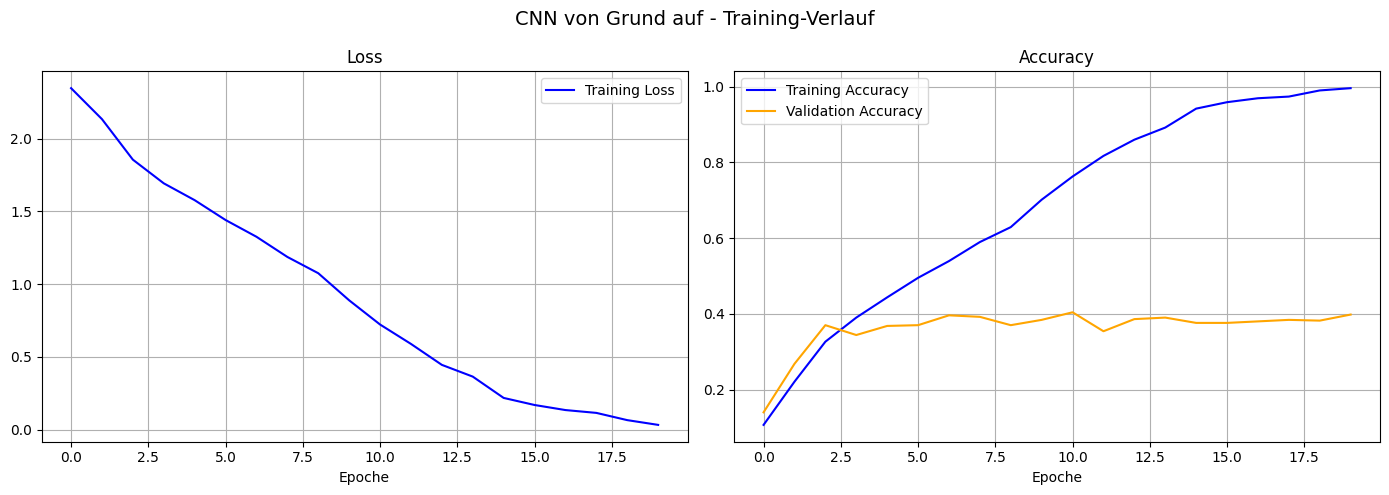

In [40]:
# Training-Verlauf visualisieren
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], color='blue', label='Training Loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoche')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history['train_acc'], color='blue',   label='Training Accuracy')
axes[1].plot(history['val_acc'],   color='orange', label='Validation Accuracy')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoche')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('CNN von Grund auf - Training-Verlauf', fontsize=14)
plt.tight_layout()
plt.savefig('training_curves_1b.png', dpi=100)
plt.show()

In [42]:
np.save('best_params_1b.npy', best_params)
print("Modell gespeichert: best_params_1b.npy")

print("\nFinale Evaluation auf Testdaten...")
test_preds = predict(x_test[:2000], best_params)
test_acc   = (test_preds == y_test[:2000]).mean()
print(f"Test Accuracy (2000 Beispiele): {test_acc:.4f} ({test_acc*100:.1f}%)")

auto_mask = (y_test[:2000] == 1)
if auto_mask.sum() > 0:
    auto_acc = (test_preds[auto_mask] == 1).mean()
    print(f"Automobil-Accuracy: {auto_acc:.4f} ({auto_acc*100:.1f}%)")

Modell gespeichert: best_params_1b.npy

Finale Evaluation auf Testdaten...
Test Accuracy (2000 Beispiele): 0.4065 (40.6%)
Automobil-Accuracy: 0.4899 (49.0%)


## Zusammenfassung

### Implementierte Komponenten
- **Conv2D**: Forward (Kreuzkorrelation) + Backward (mit gedrehtem Kernel)
- **ReLU**: Forward (max(0,x)) + Backward (Maske)
- **MaxPool**: Forward (Argmax-Maske speichern) + Backward (Gradient nur zur Max-Position)
- **Flatten**: Reshape + Rückwärts-Reshape
- **Dense**: Matrixmultiplikation + Backprop (dX=dout@W.T, dW=X.T@dout)
- **Softmax + Cross-Entropy**: Kombiniert für numerische Stabilität
- **SGD mit Momentum**: v = momentum*v - lr*grad

### Gradientencheck
Alle Schichten wurden mit numerischem Gradienten verifiziert (relativer Fehler < 1e-4).

### Einschränkungen
Die Python-Implementierung ohne Vektorkompilierung ist deutlich langsamer als Keras/TensorFlow. Die erreichbare Accuracy ist daher durch die Trainingszeit limitiert.